# Decision tree for classification

## Loading Data

In [1]:
import numpy as np
from sklearn.datasets import load_wine

In [2]:
# Load wine dataset from sklearn
wine = load_wine()
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [3]:
############################################ Task 1 ############################################
# Take attributes 'Alcohol', 'Malic acid' and 'Color intensity' as features for our further analysis
# ----------------------------------------- start here -----------------------------------------

X = wine.data[:, [0, 1, 9]]
y =  wine.target

In [4]:
X.shape

(178, 3)

In [5]:
y.shape

(178,)

## Decision Tree Diagram
<img src="dt.png" width="500"/>

## Decide What is a Good Split

#### Maximize Information Gain:

$$Gain(split\ point, feature) = Q(parent) - \left(\frac{N_{left}}{N}Q(left) + \frac{N_{right}}{N}Q(right)\right),$$

where $Q$ is the impurity of a node. Common measures of impurity are Gini and Entropy.

#### Impurity:

Let the data at node $t$ be represented by $s_t$ with $n_t$ samples. If a target is a classification outcome taking on values $0,1,\cdots,K-1$ for node $t$, let

$$p_{tk} = \frac{1}{n_t} \sum_{y \in s_t} 1(y=k)$$

be the proportion of class $k$ at node $t$. Then Gini is defined by

$$Q(s_t) = \sum_k p_{tk}(1-p_{tk}),$$

and Entropy is defined by

$$Q(s_t) = -\sum_k p_{tk}log(p_{tk}).$$

## Fitting Model

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

Accuracy:  0.8333333333333334


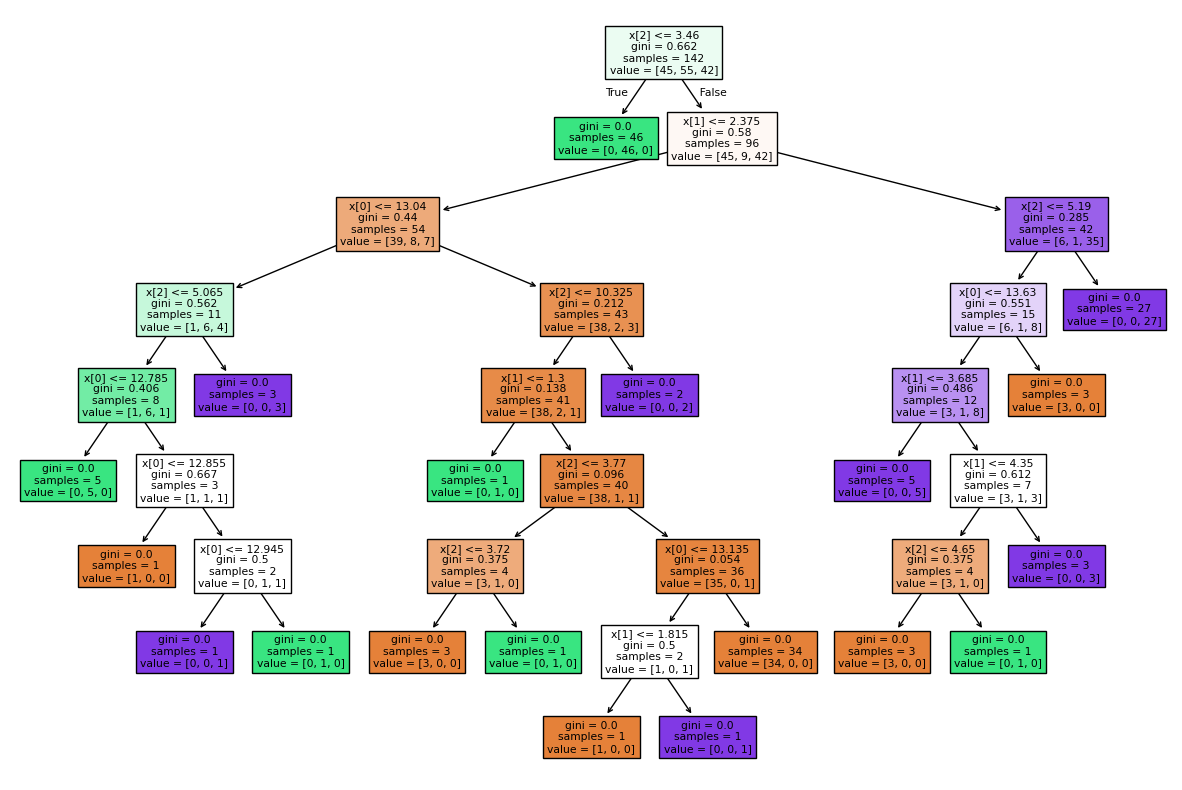

In [7]:
############################################ Task 2 ############################################
# ----------------------------------------- start here -----------------------------------------

# Split the dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Setup a DecisionTreeClassifier with the Gini index as criterion
dtc = DecisionTreeClassifier(criterion="gini", random_state=0)

# Fit DecisionTreeClassifier with training data
dtc.fit(X_train, y_train)

# Predict data in test set with DecisionTreeClassifier
y_pred = dtc.predict(X_test)

# Calculate the accuracy of predictions
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy on the test set
print('Accuracy: ', accuracy)

# Display the learned classifier
plt.figure(figsize=(15, 10))
plot_tree(dtc, filled=True)
plt.show()

## Cost Complexity Pruning

Let $t$ be a node of the given tree $T$, and $T_t$ its branch, then the effective $\alpha$ of a node is defined as

$$\alpha_{eff}(t) = \frac{R(t) - R(T_t)}{|T| - 1},$$

where

$R(T_t)$: sum of weighted impurity of all leaf nodes in the entire subtree $T_t$ rooted at node t

$R(t)$: weighted impurity of a single node t.

A non-terminal node with the smallest value of $\alpha_{eff}(t)$ is the weakest link and will be pruned. This process stops when the pruned tree’s minimal $\alpha_{eff}(t)$ is greater than the ccp_alpha parameter.

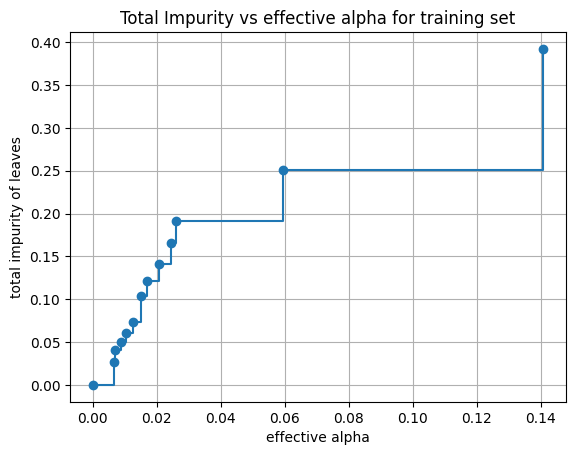

In [8]:
############################################ Task 3 ############################################
# Use cost_complexity_pruning_path to display the resulting impurity in the pruned trees
# ----------------------------------------- start here -----------------------------------------

# Use cost_complexity_pruning_path to return the effective alphas and the corresponding total leaf impurities
path = dtc.cost_complexity_pruning_path(X_train, y_train)
effective_alphas, impurities = path.ccp_alphas, path.impurities

# Plot the relationship of the effective alphas and the total leaf impurities
fig, ax = plt.subplots()
ax.plot(effective_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
ax.grid()

In [9]:
effective_alphas

array([0.        , 0.00677817, 0.00704225, 0.00880282, 0.01056338,
       0.01273617, 0.01525822, 0.01713615, 0.02064661, 0.0243503 ,
       0.02595573, 0.05945524, 0.14080548, 0.26990552])

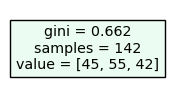

In [10]:
############################################ Task 3 ############################################
# Display the decision tree with the highest and second highest effective alpha value
# ----------------------------------------- start here -----------------------------------------

# Setup a DecisionTreeClassifier with the highest effective alpha value
dtc = DecisionTreeClassifier(criterion='gini', ccp_alpha=effective_alphas[-1])

# Fit DecisionTreeClassifier with training data
dtc.fit(X_train, y_train)
# Plot the DecisionTreeClassifier
plt.figure(figsize=(2, 1))
plot_tree(dtc, filled=True)
plt.show()

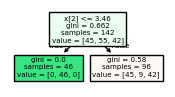

In [11]:
############################################ Task 3 ############################################
# Display the decision tree with the second highest effective alpha value
# ----------------------------------------- start here -----------------------------------------

# Setup a DecisionTreeClassifier with the second highest effective alpha value
dtc = DecisionTreeClassifier(criterion='gini', ccp_alpha=effective_alphas[-2])
# Fit DecisionTreeClassifier with training data
dtc.fit(X_train, y_train)
# Plot the DecisionTreeClassifier
plt.figure(figsize=(2, 1))
plot_tree(dtc, filled=True)
plt.show()

In [12]:
ccp_alphas

NameError: name 'ccp_alphas' is not defined

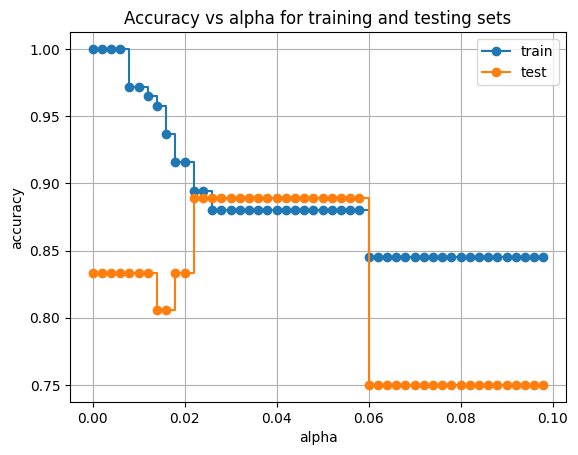

In [13]:
############################################ Task 3 ############################################
# Study the empirical and test error/risk of the pruned tree for α ∈ {0, 0.002, 0.004, 0.006, ... , 0.998, 0.1}.
# ----------------------------------------- start here -----------------------------------------

# Setup decision tree with different values of ccp_alpha
ccp_alphas = np.arange(0, 0.1, 0.002)
dtcs_alpha = [] # List of decision trees with different values of ccp_alpha
for ccp_alpha in ccp_alphas:
    dtc_alpha = DecisionTreeClassifier(criterion="gini", ccp_alpha=ccp_alpha)
    dtc_alpha.fit(X_train, y_train)
    dtcs_alpha.append(dtc_alpha)

# Compare the accuracy of training set and test set with different ccp_alpha values
train_scores = [dtc.score(X_train, y_train) for dtc in dtcs_alpha]
test_scores = [dtc.score(X_test, y_test) for dtc in dtcs_alpha]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
ax.grid()
plt.show()

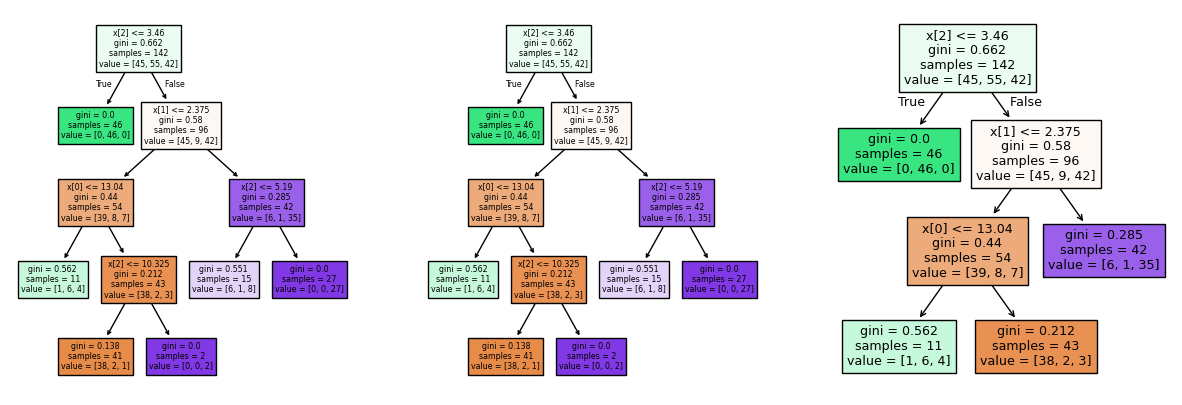

In [17]:
############################################ Task 3 ############################################
# Display the decision tree(s) with the highest test accuracy
# ----------------------------------------- start here -----------------------------------------

fig = plt.figure(figsize=(15,5))
ccp_alphas = [0.022, 0.024, 0.026]

for i,alpha in enumerate(ccp_alphas):
    
    plt.subplot(1, len(ccp_alphas), i+1)
    
    # Setup a DecisionTreeClassifier with highest alpha value
    dtc = DecisionTreeClassifier(criterion="gini", ccp_alpha=alpha)

    # Fit DecisionTreeClassifier with training data
    dtc.fit(X_train, y_train)

    # Plot the DecisionTreeClassifier
    plot_tree(dtc, filled=True)
    
plt.show()

## GridSearchCV

In [18]:
from sklearn.model_selection import GridSearchCV

max_features: The number of features to consider when looking for the best split.

* If “sqrt”, then max_features=sqrt(n_features)

* If “log2”, then max_features=log2(n_features)

* If None, then max_features=n_features

In [22]:
############################################ Task 4 ############################################
# Perform a grid search to find the best combination of criterion for impurity, 
# maximum number of features, and effective alpha value
# ----------------------------------------- start here -----------------------------------------

# Construct a DecisionTreeClassifier
dtc_gs = DecisionTreeClassifier()

# Setup GridSearchCV
params = {
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None],
    'ccp_alpha': np.arange(0, 0.1, 0.002),
          }

gs = GridSearchCV(estimator=dtc_gs, param_grid=params, scoring='accuracy', cv=5)

# Fit GridSearchCV
gs.fit(X_train, y_train)

# Print the best combination of parameters
print(gs.best_params_)

{'ccp_alpha': np.float64(0.01), 'criterion': 'gini', 'max_features': None}


In [26]:
############################################ Task 4 ############################################
# Train a decision tree for the found best combination and estimate its generalization error
# ----------------------------------------- start here -----------------------------------------

# Set up a DecisionTreeClassifier with the best parameters
dtc_best = DecisionTreeClassifier(ccp_alpha=gs.best_params_['ccp_alpha'], criterion=gs.best_params_['criterion'], max_features=gs.best_params_['max_features'])

# Fit the DecisionTreeClassifier model
dtc_best.fit(X_train, y_train)

# Predict test data with the DecisionTreeClassifier model
y_pred = dtc_best.predict(X_test)

# Calculate the accuracy of predictions
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy
print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


## Add more features

In [28]:
from sklearn.model_selection import cross_val_score

In [30]:
############################################ Task 5 ############################################
# Increase the number of features starting with the chosen three features alcohol, malic acid,
# and color intensity and adding the other available features one by one
# ----------------------------------------- start here -----------------------------------------

# Get feature indices
num_features = wine.data.shape[1]
base_features = [0,1,9] # 'alcohol', 'malic acid', and 'color intensity'
all_features = list(range(num_features))

# Build feature addition list
feature_order = base_features + [f for f in all_features if f not in base_features]
feature_order

[0, 1, 9, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12]

In [31]:
len(feature_order)

13

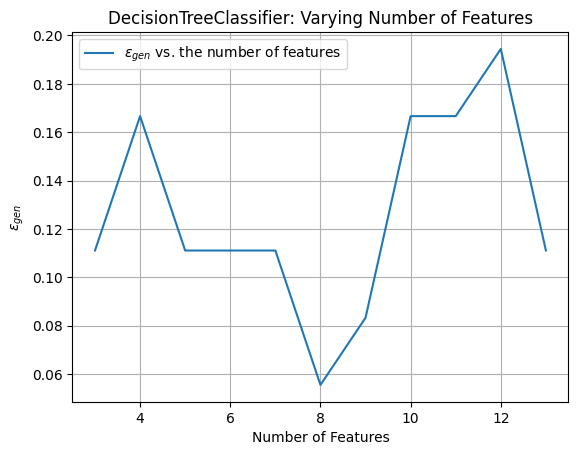

In [35]:
############################################ Task 5 ############################################
# Search each time the best combination of criterion for impurity, maximum number of features,
# and effective alpha value. Report the resulting estimates for the generalization error versus the number of features.
# ----------------------------------------- start here -----------------------------------------

error_gs = []

for i in range(3, len(feature_order) + 1):
    
    # Increase features gradually
    selected = feature_order[:i]
    X_cv = wine.data[:, selected]
    y_cv = wine.target
    
    # Split the dataset into 80% train, 20% test
    X_train, X_test, y_train, y_test = train_test_split(X_cv, y_cv, test_size=0.2, random_state=0)
    
    # Set up GridSearchCV
    gs = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=params, scoring='accuracy', cv=5, refit=True) 
   
    # Fitting the model for grid search 
    gs.fit(X_train, y_train)

    # Predict test data
    y_pred_gs = gs.predict(X_test)    
    # Calculate the accuracy of predictions
    accuracy_gs = accuracy_score(y_test, y_pred_gs)
    
    # Add the accuracy of GridSearchCV to a list
    error_gs.append(1-accuracy_gs)
    
# Plot cross validaton errors
plt.title("DecisionTreeClassifier: Varying Number of Features")
plt.plot(np.arange(3,14), error_gs, label=r"$ \epsilon_{gen} $ vs. the number of features")
plt.xlabel("Number of Features")
plt.ylabel(r"$ \epsilon_{gen}$")
plt.legend()
plt.grid()
plt.show()

## Features Importances

Let $f$ represent a feature and $t$ be a node of the given tree $T$, then

$$Importance(f) = \sum_{t\in T} \frac{N_t}{N} Gain_t(\cdot,f),$$

where $N_t/N$ is the proportion of samples reaching t, $Gain_t(\cdot,f)$ is the information gain of nodes $t$ brought by feature $f$.

In [36]:
import pandas as pd

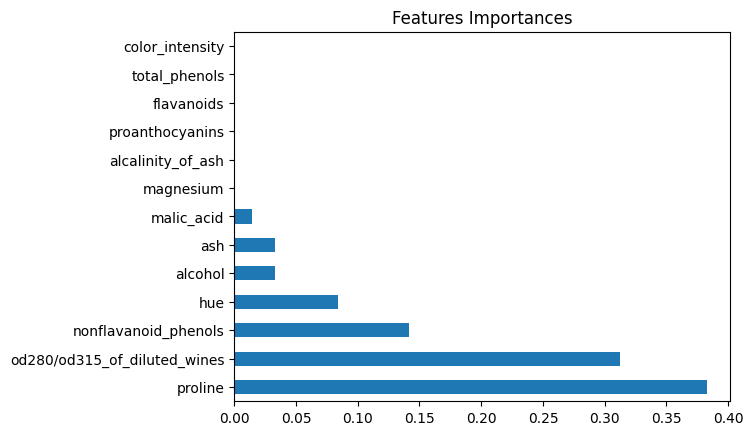

In [38]:
############################################ Task 5 ############################################
# Study the importance of all features
# ----------------------------------------- start here -----------------------------------------

# Fit previous DecisionTreeClassifier with full dataset
dtc_gs.fit(X_cv, y_cv)

# Create a pd.Series of features importances
importances = pd.Series(data=dtc_gs.feature_importances_, index=wine.feature_names)

# Sort importances
importances_sorted = importances.sort_values(ascending=False)

# Draw a horizontal barplot of importances_sorted
importances_sorted.plot(kind='barh')
plt.title('Features Importances')
plt.show()

In [39]:
############################################ Task 5 ############################################
# Reorder the features according the their estimated importance
# ----------------------------------------- start here -----------------------------------------

# Create a pd.Series of features importances
importances = pd.Series(data=dtc_gs.feature_importances_)

# Sort importances
index_list = importances.sort_values(ascending=False)

In [40]:
index_list

,0
12,0.382470
11,0.312043
7,0.141447
10,0.083787
0,0.033052
2,0.032978
1,0.014223
4,0.000000
3,0.000000
8,0.000000


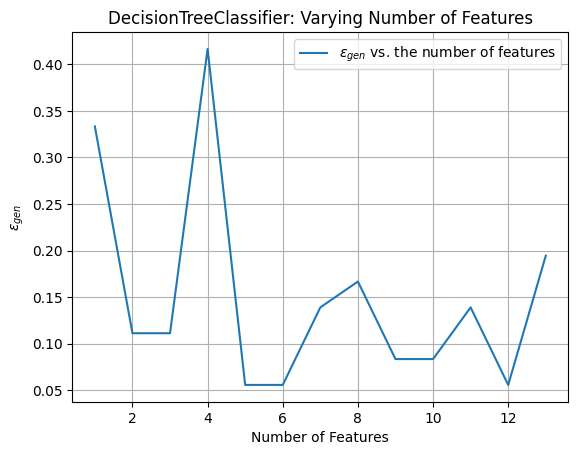

In [41]:
############################################ Task 5 ############################################
# Add now the features one by one, perform grid search, and report the estimates
# for the generalization error versus the number of sorted features
# ----------------------------------------- start here -----------------------------------------

errors_gs = []
selected = []

for i in index_list.index:
    
    selected.append(i)
    
    # Increase features gradually
    X_cv = wine.data[:, selected]
    y_cv = wine.target
    
    # Split the dataset into 80% train, 20% test
    X_train, X_test, y_train, y_test = train_test_split(X_cv, y_cv, test_size=0.2, random_state=0)
    
    # Set up GridSearchCV
    gs = GridSearchCV(estimator=dtc_gs, param_grid=params, scoring='accuracy', cv=5, refit=True) 
   
    # Fitting the model for grid search 
    gs.fit(X_train, y_train)

    # Predict test data
    y_pred_gs = gs.predict(X_test)
    
    # Calculate the accuracy of predictions
    accuracy_gs = accuracy_score(y_test, y_pred_gs)

    # Add the accuracy of GridSearchCV to a list
    errors_gs.append(1-accuracy_gs)
    
# Plot cross validaton errors
plt.title("DecisionTreeClassifier: Varying Number of Features")
plt.plot(np.arange(1,14), errors_gs, label=r"$ \epsilon_{gen} $ vs. the number of features")
plt.xlabel("Number of Features")
plt.ylabel(r"$ \epsilon_{gen}$")
plt.legend()
plt.grid()
plt.show()